In [ ]:
from utils import *


<h1 align='center'> Addressing possible confounds </h1>

## Temporal and character familiarity similarity can't explain the dimension effect

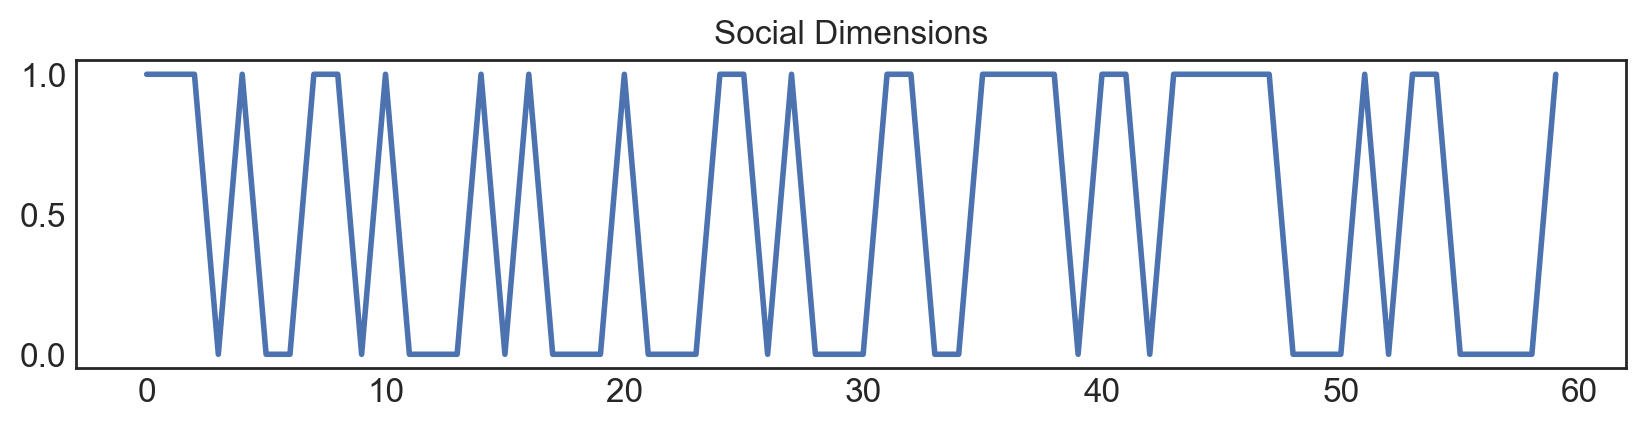

Levene test for equal variance: p=0.587
T-test for familiarity difference: t=-0.601, p=0.548
Levene test for equal variance: p=0.256
T-test for onset closeness: t=-0.458, left-tailed p=0.647


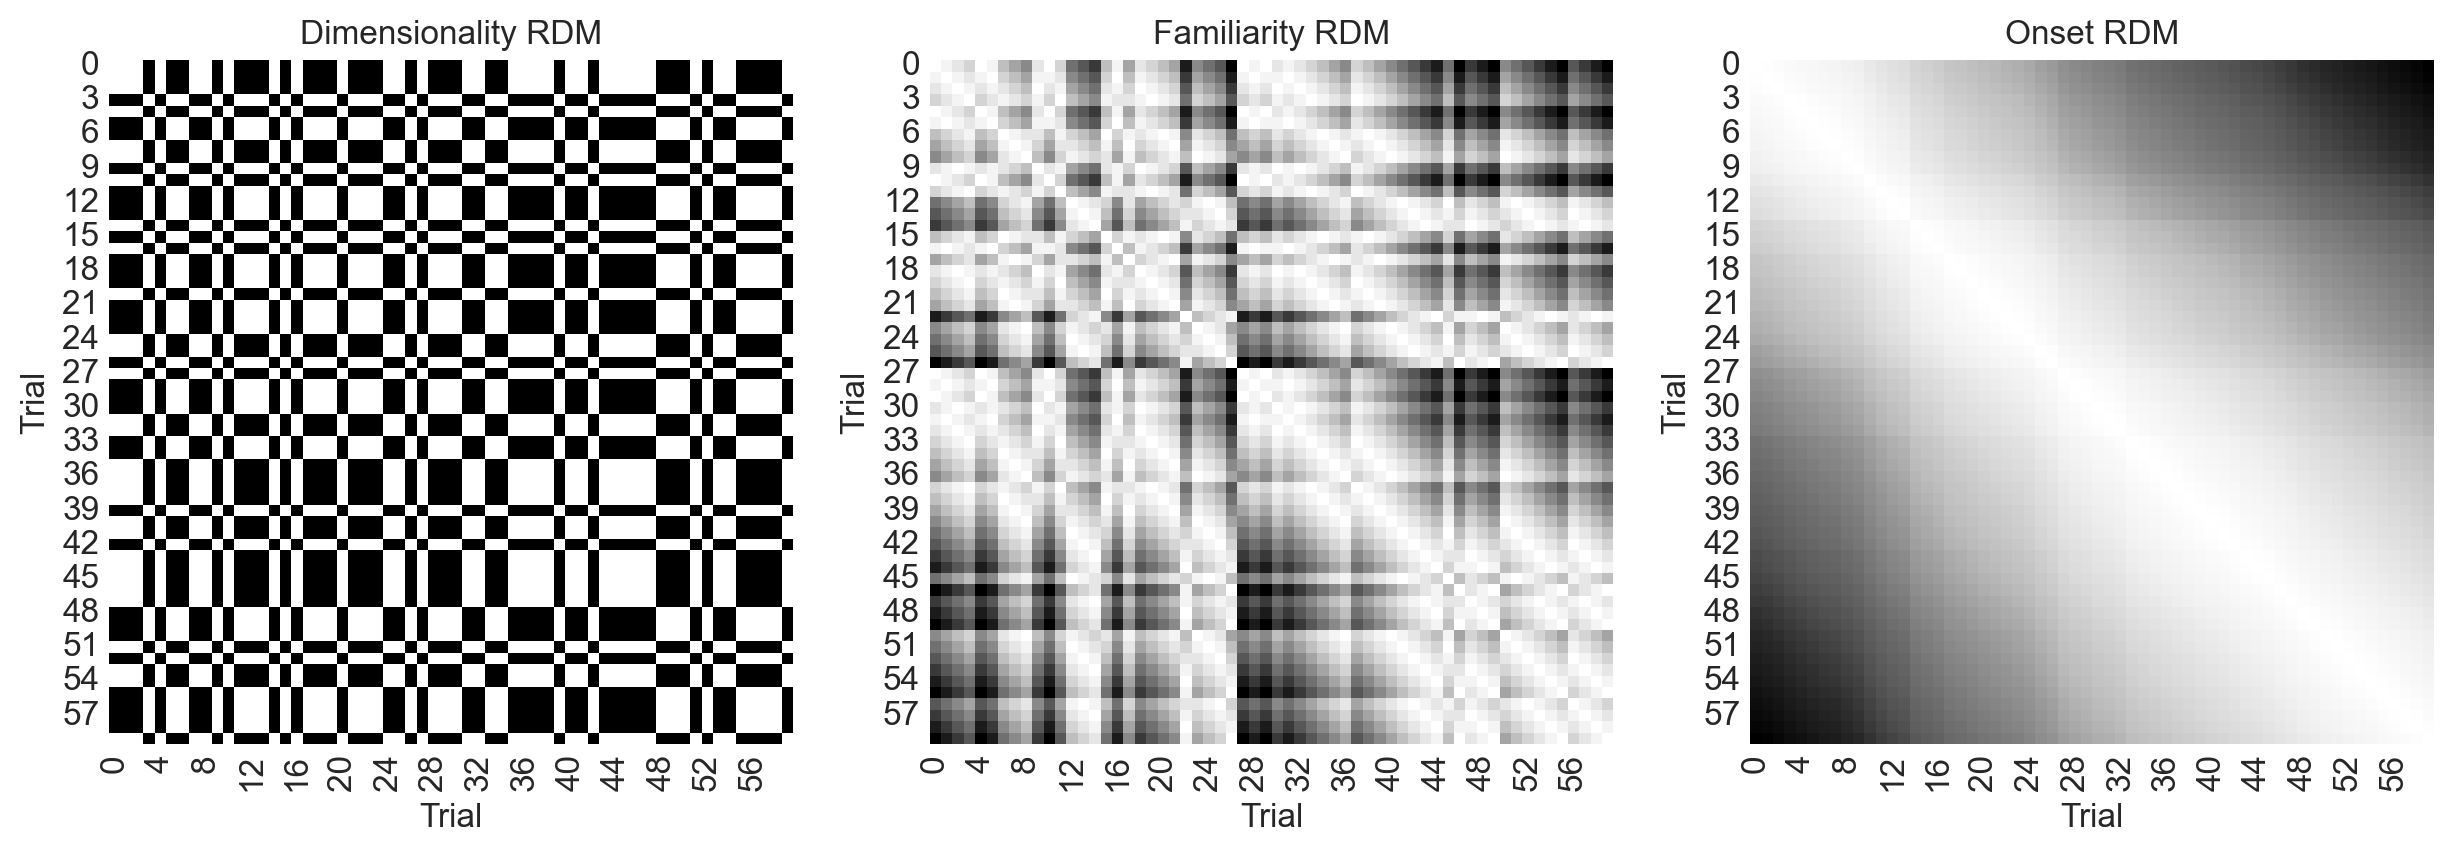

In [ ]:
# plot the individual trials
affil = remove_neutral_trials((decision_trials['dimension'] == 'affil').values.astype(int))[:, np.newaxis]
fig, ax = plt.subplots(figsize=(10, 2))
ax.plot(affil)
ax.set_title('Social Dimensions')
plt.show()

dim_rdm = pairwise_distances(affil, metric='hamming')
dim_rdv = flatten_upper_tri(dim_rdm)

# compare dimensions on familiarity
familiarity      = remove_neutral_trials(decision_trials['character_decision_num'].values)
familiarity_rdm  = pairwise_distances(familiarity.reshape(-1, 1), metric='euclidean')
familiarity_rdv  = flatten_upper_tri(familiarity_rdm)
familiarity_same = familiarity_rdv[dim_rdv==1]
familiarity_diff = familiarity_rdv[dim_rdv==0]

p = scipy.stats.levene(familiarity_same, familiarity_diff)[1]
print(f'Levene test for equal variance: p={p:.3f}')
t, p = scipy.stats.ttest_ind(familiarity_same, familiarity_diff, equal_var=True)
print(f'T-test for familiarity difference: t={t:.3f}, p={p:.3f}')

# compare dimensions on onsets
onsets     = remove_neutral_trials(decision_trials['onset'].values)
onset_rdm  = pairwise_distances(onsets.reshape(-1, 1), metric='euclidean')
onset_rdv  = flatten_upper_tri(onset_rdm)
onset_same = onset_rdv[dim_rdv==1]
onset_diff = onset_rdv[dim_rdv==0]

p = scipy.stats.levene(onset_same, onset_diff)[1]
print(f'Levene test for equal variance: p={p:.3f}')
t, p = scipy.stats.ttest_ind(onset_same, onset_diff, equal_var=True) # even 1-sided isnt significant
print(f'T-test for onset closeness: t={t:.3f}, left-tailed p={p:.3f}')


#-------------
# plot heatmap
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

ax = axs[0]
sns.heatmap(dim_rdm, cmap='Greys', square=True, ax=ax)
ax.set(title='Dimensionality RDM', xlabel='Trial', ylabel='Trial')
ax.collections[0].colorbar.remove()

ax = axs[1]
sns.heatmap(familiarity_rdm, cmap='Greys', square=True, ax=ax)
ax.set(title='Familiarity RDM', xlabel='Trial', ylabel='Trial')
ax.collections[0].colorbar.remove()

ax = axs[2]
sns.heatmap(onset_rdm, cmap='Greys', square=True, ax=ax)
ax.set(title='Onset RDM', xlabel='Trial', ylabel='Trial')
ax.collections[0].colorbar.remove()
plt.show()

## Word count can't explain it

In [ ]:
affil_mask = decision_trials['dimension'] == 'affil'
power_mask = decision_trials['dimension'] == 'power'

In [ ]:
# import Dict from typing
from typing import Dict
def replace_pronouns(df: pd.DataFrame, character_genders: Dict[str, str]) -> pd.DataFrame:
    """
    Replace bracketed placeholders in columns ['text','opt1_text','opt2_text'] using only
    the provided character_genders mapping:
      {'First': 'man'/'woman', 'Second': ..., 'Assistant': ..., 'Newcomb': ..., 'Hayworth': ..., 'Neutral': ...}

    Behavior
    --------
    • Pronouns for each role (subject/object/possessives/reflexive) and contractions ('is','would','will')
    • Titles/specials: [Mr./Mrs. X character], [X character sir/ma'am], [X character guy/girl], [X character man/woman]
    • Names:
        - First & Second:     man→Chris  | woman→Jessica
        - Assistant & Neutral: man→Anthony | woman→Kayce
        - Newcomb & Hayworth: fixed "Newcomb" / "Hayworth"
      Replaces: [X character name], [X character first name]
    • Newcomb possessive: [Newcomb character possessive] → "Newcomb's"
      (others: → his/her according to gender)
    • Newcomb spouse: opposite Newcomb gender; name = "James" (man) or "Mary" (woman)
      Replaces: [Newcomb character spouse's name], [Newcomb character spouse's pronoun]
    • Any unrecognized tokens are left as-is.

    Notes
    -----
    • Female title is "Mrs." (per your preference).
    """

    required_cols = {'text','opt1_text','opt2_text'}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"DataFrame missing required columns: {missing}")

    # ---------- helpers ----------
    def forms_for_gender(g: str):
        g = (g or '').strip().lower()
        if g == 'woman':
            return dict(
                subj='she', obj='her', poss_det='her', poss_pron='hers', refl='herself',
                is_contr="she's", would_contr="she'd", will_contr="she'll",
                guy_girl='girl', sir_maam="ma'am", man_woman='woman', mr_mrs='Mrs.'
            )
        # default to 'man'
        return dict(
            subj='he', obj='him', poss_det='his', poss_pron='his', refl='himself',
            is_contr="he's", would_contr="he'd", will_contr="he'll",
            guy_girl='guy', sir_maam='sir', man_woman='man', mr_mrs='Mr.'
        )

    def name_for_role(role: str, gender: str) -> str:
        gender = (gender or 'man').lower()
        if role in ('First', 'Second'):
            return 'Chris' if gender == 'man' else 'Jessica'
        if role in ('Assistant', 'Neutral'):
            return 'Anthony' if gender == 'man' else 'Kayce'
        if role == 'Newcomb':
            return 'Newcomb'
        if role == 'Hayworth':
            return 'Hayworth'
        # fallback
        return role

    roles = ['First','Second','Assistant','Newcomb','Hayworth','Neutral']
    role_forms = {r: forms_for_gender(character_genders.get(r, 'man')) for r in roles}
    role_names = {r: name_for_role(r, character_genders.get(r, 'man')) for r in roles}

    # Newcomb spouse (opposite gender)
    newcomb_gender = (character_genders.get('Newcomb','man') or 'man').lower()
    spouse_gender = 'woman' if newcomb_gender == 'man' else 'man'
    spouse_forms = forms_for_gender(spouse_gender)
    spouse_name = 'Mary' if spouse_gender == 'woman' else 'James'

    # ---------- build replacement rules ----------
    replacements = []
    def pat(token: str) -> re.Pattern:
        return re.compile(re.escape(token))

    for role in roles:
        f = role_forms[role]
        nm = role_names[role]
        # Core pronouns + contractions
        mapping = {
            f'[{role} character pronoun]': f['subj'],
            f'[{role} character objective]': f['obj'],
            f'[{role} character reflexive]': f['refl'],
            f'[{role} character possessive pronoun]': f['poss_pron'],
            f'[{role} character possessive determiner]': f['poss_det'],
            f'[{role} character \'is\' contraction]': f['is_contr'],
            f'[{role} character \'would\' contraction]': f['would_contr'],
            f'[{role} character \'will\' contraction]': f['will_contr'],
            f'[Mr./Mrs. {role} character]': f['mr_mrs'],
            f'[{role} character sir/ma\'am]': f['sir_maam'],
            f'[{role} character guy/girl]': f['guy_girl'],
            f'[{role} character man/woman]': f['man_woman'],
            f'[{role} character name]': nm,
            f'[{role} character first name]': nm,
        }
        # Generic "[X character possessive]" → pronoun poss. determiner, except Newcomb handled later
        if role != 'Newcomb':
            mapping[f'[{role} character possessive]'] = f['poss_det']

        for k, v in mapping.items():
            replacements.append((pat(k), v))

    # Newcomb-specific overrides & spouse
    replacements.append((pat('[Newcomb character possessive]'), "Newcomb's"))
    replacements.append((pat("[Newcomb character spouse's name]"), spouse_name))
    replacements.append((pat("[Newcomb character spouse's pronoun]"), spouse_forms['subj']))

    # Also ensure explicit tokens common in your script map correctly
    replacements.append((pat("[Hayworth character sir/ma'am]"), role_forms['Hayworth']['sir_maam']))
    replacements.append((pat('[Second character guy/girl]'), role_forms['Second']['guy_girl']))
    replacements.append((pat('[Newcomb character man/woman]'), role_forms['Newcomb']['man_woman']))

    # Cleanup: collapse double spaces that might arise after substitutions
    space_fix = re.compile(r' {2,}')

    def _apply(text):
        if not isinstance(text, str):
            return text
        out = text
        for rx, repl in replacements:
            out = rx.sub(repl, out)
        out = space_fix.sub(' ', out)
        return out

    out = df.copy()
    for col in ['text','opt1_text','opt2_text']:
        out[col] = out[col].map(_apply)

    return out

from nltk.tokenize import word_tokenize, sent_tokenize

# get the text for the decision trials
character_genders = {'First': 'man', 'Second': 'woman', 'Assistant': 'man',
                    'Newcomb': 'woman', 'Hayworth': 'man', 'Neutral': 'woman'}
decision_trials = replace_pronouns(decision_trials, character_genders)
affil_df   = decision_trials[affil_mask].reset_index(drop=True)
power_df   = decision_trials[power_mask].reset_index(drop=True)
assert affil_df.shape[0] == power_df.shape[0]

# number of words
affil_wc = np.array([len(set(word_tokenize(text))) for text in affil_df['text'].values])
power_wc = np.array([len(set(word_tokenize(text))) for text in power_df['text'].values])

print("Mean affiliation words:", affil_wc.mean())
print("Mean power words:", power_wc.mean())
t_stat, p = scipy.stats.ttest_ind(affil_wc, power_wc, alternative='two-sided')
print(f'Word count: t={t_stat:.3f}, p={p:.3f}')

Mean affiliation words: 26.633333333333333
Mean power words: 25.6
Word count: t=0.593, p=0.555


## Sentiment can't explain it

In [ ]:
#---------------------------------------- sentiment analysis

from transformers import pipeline
sentiment_model = pipeline("sentiment-analysis", 
                           model="cardiffnlp/twitter-roberta-base-sentiment", 
                           return_all_scores=True) 

def calculate_compound_score(sentiment):
    
    positive = sentiment[[k for k in sentiment.keys() if 'positivity' in k][0]]
    negative = sentiment[[k for k in sentiment.keys() if 'negativity' in k][0]]
    neutral  = sentiment[[k for k in sentiment.keys() if 'neutrality' in k][0]]

    # Normalize scores --> probabilities
    total = positive + negative + neutral
    positive_norm = positive / total
    negative_norm = negative / total
    neutral_norm  = neutral / total
    
    # Simple compound score calculation
    # - scale by neutral to reduce the compound score when the sentiment is mostly neutral
    compound_score = (positive_norm - negative_norm) * (1 - neutral_norm)
    return np.round(compound_score, 3)

def run_sentiment_analysis(text):
    sentiment = sentiment_model(text)[0]
    sentiment = {sent['label']: np.round(sent['score'], 3) for sent in sentiment}
    label_mapping = {'LABEL_0': 'negativity', 'LABEL_1': 'neutrality', 'LABEL_2': 'positivity'} 
    sentiment = {label_mapping[k]: v for k, v in sentiment.items() if k in label_mapping}
    sentiment['compound'] = calculate_compound_score(sentiment)
    return sentiment

sentiments = [run_sentiment_analysis(text) for text in decision_trials['text']]
sentiment_df = pd.DataFrame(sentiments)
decision_trials[sentiment_df.columns] = sentiment_df


# compare affil and pwoer on compound 
t_stat, p = scipy.stats.ttest_ind(decision_trials.loc[affil_mask, 'compound'], 
                                  decision_trials.loc[power_mask, 'compound'], 
                                  alternative='two-sided')
print(f'Compound sentiment: t={t_stat:.3f}, p={p:.3f}')

Device set to use mps:0


## Reaction time is a confound

In [ ]:
rt_diffs = []
for sub_id in data['sub_id'].values:
    behav = load_behavior(sub_id, neutrals=False)
    behav = behav[behav['responded']].reset_index()
    affil_rts = behav[behav['dimension'] == 'affil']['reaction_time']
    power_rts = behav[behav['dimension'] == 'power']['reaction_time']
    rt_diffs.append([sub_id, np.mean(affil_rts), np.mean(power_rts)])
rt_df = pd.DataFrame(rt_diffs, columns=['sub_id', 'affil_rt', 'power_rt'])
# print the means
print(rt_df[['affil_rt', 'power_rt']].mean())

t, p = scipy.stats.ttest_rel(rt_df['affil_rt'], rt_df['power_rt'])
print(f'RT difference: t={t:.3f}, p={p:.3f}')
fig, ax = plt.subplots(figsize=(5, 3))
sns.histplot(rt_df['affil_rt'], color='blue', ax=ax, label='Affil')
sns.histplot(rt_df['power_rt'], color='red', ax=ax, label='Power')
ax.set(title='Reaction Times', xlabel='Mean RT', ylabel='Count')
plt.legend();

## Semantics are different, as expected

Running permutations: 100%|██████████| 1000/1000 [00:00<00:00, 8229.43it/s]


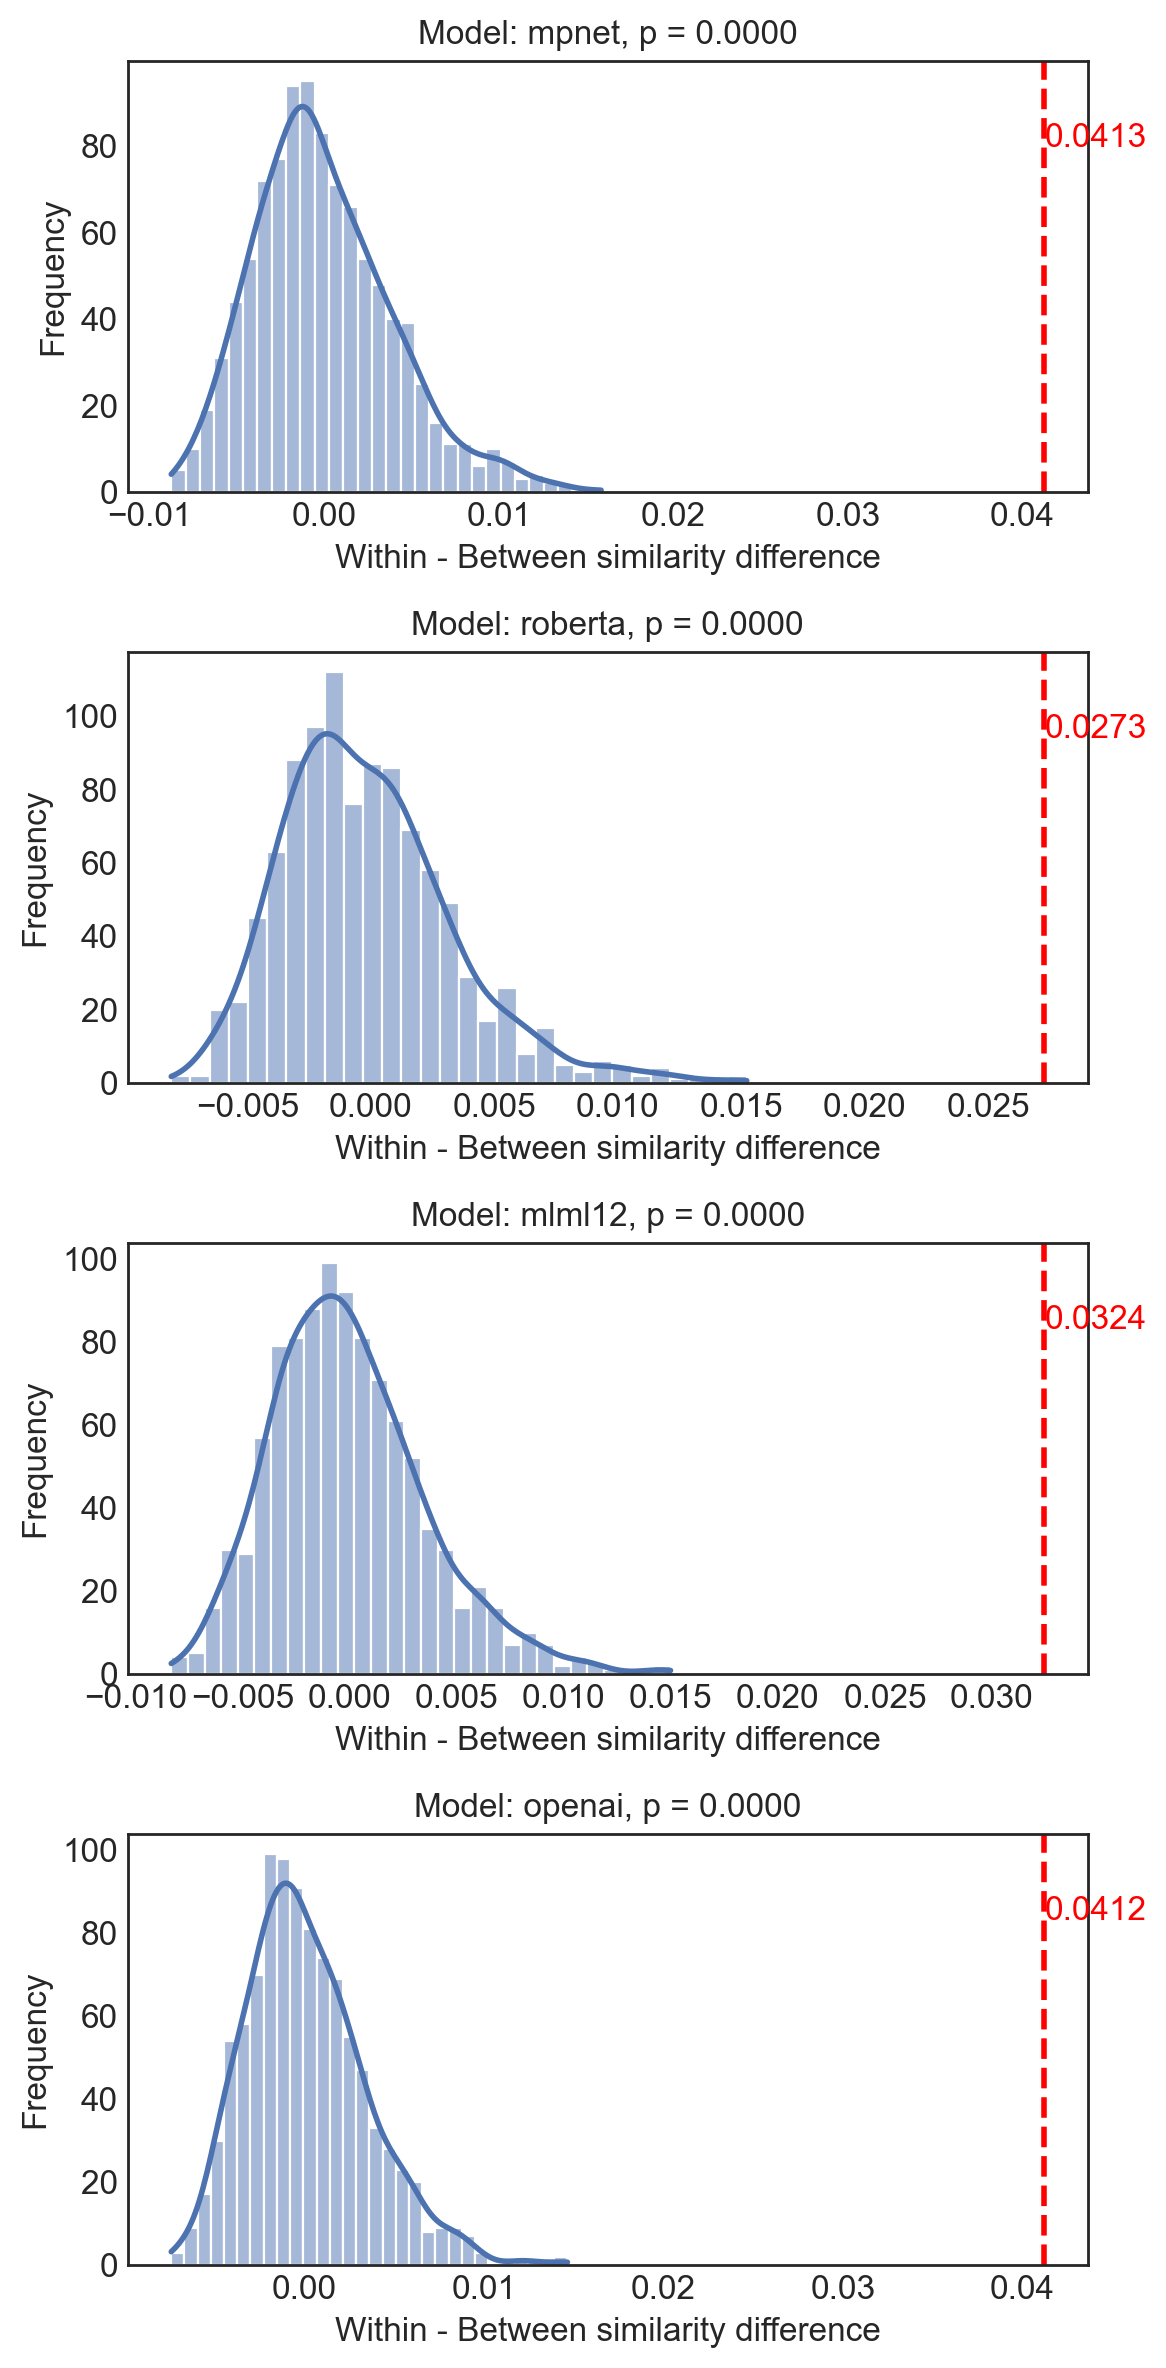

In [ ]:
snt_df = pd.read_excel(f'{data_dir}/info/social-navigation-task.xlsx')
snt_df = snt_df[np.isfinite(snt_df['trial_num'])]
snt_df.sort_values(by='onset', inplace=True)
decision_mask = (snt_df['slide_type'] == 'Decision').values
affil_decisions = ((decision_trials['dimension'] == 'affil').values)*1

model_names  = ['mpnet', 'google']
semantic_dict = load_pickle(f'../data/narratives/task-embeddings/generic_narrative_embeddings_1slide-context.pkl')


# Permutation test function that works with pre-computed dimension RDV
def permutation_test_dimension_similarity(vectors, dimension_labels, n_permutations=1000):
    """
    Run a permutation test to determine if within-dimension similarity is greater than between-dimension similarity.
    
    Parameters:
    -----------
    vectors : ndarray
        Decision vectors with shape (n_samples, n_features)
    dimension_labels : ndarray
        Binary column vector indicating the dimension of each vector (e.g., affil_decisions)
    n_permutations : int
        Number of permutations to run
    
    Returns:
    --------
    observed_diff : float
        Observed difference between within-dimension and between-dimension similarities
    p_value : float
        P-value from the permutation test
    null_diffs : ndarray
        Distribution of differences under the null hypothesis
    """
    # Calculate pairwise cosine similarities (1 - cosine distance)
    similarity_matrix = 1 - pairwise_distances(vectors, metric='cosine')
    
    # Convert dimension labels to a vector if it's a column
    if dimension_labels.ndim > 1 and dimension_labels.shape[1] == 1:
        dimension_labels = dimension_labels.ravel()
    
    # Create dimension RDV: 0 if same dimension, 1 if different
    dimension_rdv = flatten_upper_tri(pairwise_distances(dimension_labels[:, np.newaxis], metric='hamming'))
    
    # Get similarity values (upper triangular, excluding diagonal)
    similarity_values = flatten_upper_tri(similarity_matrix)
    
    # Separate within and between similarities
    within_similarities = similarity_values[dimension_rdv == 0]  # Same dimension (0 distance)
    between_similarities = similarity_values[dimension_rdv == 1]  # Different dimensions (1 distance)
    
    # Calculate observed statistic: difference between within and between similarities
    observed_diff = np.mean(within_similarities) - np.mean(between_similarities)
    
    # Permutation test
    null_diffs = np.zeros(n_permutations)
    for i in tqdm(range(n_permutations), desc="Running permutations"):
        # Permute dimension labels
        permuted_labels = np.random.permutation(dimension_labels)
        
        # Create permuted dimension RDV
        permuted_rdv = flatten_upper_tri(pairwise_distances(permuted_labels[:, np.newaxis], metric='hamming'))
        
        # Calculate null difference
        null_within = similarity_values[permuted_rdv == 0]
        null_between = similarity_values[permuted_rdv == 1]
        null_diffs[i] = np.mean(null_within) - np.mean(null_between)
    
    # Calculate p-value
    p_value = np.mean(null_diffs >= observed_diff)
    
    return observed_diff, p_value, null_diffs

# Modified main analysis
def run_permutation_analysis(semantic_vectors, decision_mask, affil_decisions, n_permutations=1000):
    """Run the permutation analysis for all models."""
    results = []
    
    for model_name, vectors in semantic_vectors.items():

        if model_name == 'text':
            continue  # Skip the text entries

        # Extract decision vectors
        decision_vectors = remove_neutral_trials(vectors[decision_mask])
        
        # Get the binary dimension labels that correspond to the decision vectors
        dimension_labels = remove_neutral_trials(affil_decisions)
        
        # Make sure vectors and labels match in length
        assert len(decision_vectors) == len(dimension_labels), f"Mismatch in dimensions: {len(decision_vectors)} vectors but {len(dimension_labels)} labels"
        
        # Run permutation test
        diff, p_value, null_distribution = permutation_test_dimension_similarity(
            decision_vectors, dimension_labels, n_permutations
        )
        
        # Store results
        results.append({
            'model': model_name,
            'diff': diff,
            'p_value': p_value,
            'null_distribution': null_distribution
        })
    
    return results

results = run_permutation_analysis(semantic_dict, decision_mask, affil_decisions, n_permutations=1000)

# Create DataFrame for results summary
summary_df = pd.DataFrame([
    {'model': r['model'], 'diff': r['diff'], 'p_value': r['p_value']}
    for r in results
])

fig, axs = plt.subplots(len(results), 1, figsize=(6, 3* len(results)))
for i, result in enumerate(results):
    ax = axs[i]
    sns.histplot(result['null_distribution'], ax=ax, bins=30, kde=True)
    ax.axvline(result['diff'], color='red', linestyle='--')
    # add text next to the line result['diff']
    ax.text(result['diff'], ax.get_ylim()[1] * 0.8, f"{result['diff']:.4f}", color='red')
    ax.set_title(f"Model: {result['model']}, p = {result['p_value']:.4f}")
    ax.set_xlabel("Within - Between similarity difference")
    ax.set_ylabel("Frequency")
plt.tight_layout()
